In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('/content/placement.csv')

In [3]:

df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [5]:
df = df.iloc[:,1:]

In [6]:

df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [7]:
import matplotlib.pyplot as plt

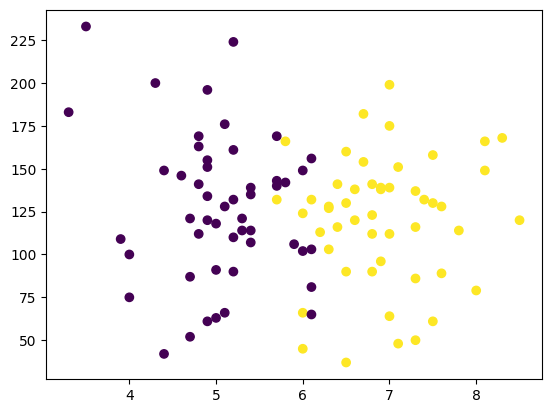

In [8]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [9]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [10]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
scaler = StandardScaler()

In [14]:
X_train = scaler.fit_transform(X_train)

In [15]:
X_train

array([[-0.92684406, -1.63402169],
       [ 0.03296307, -2.03617367],
       [ 1.60355657, -0.30189326],
       [ 0.81825982,  0.32646921],
       [ 0.03296307, -0.05054827],
       [ 0.99277021,  0.6280832 ],
       [ 0.90551501,  1.83453914],
       [ 1.86532215,  1.00510068],
       [ 0.55649424,  0.30133471],
       [ 0.73100463, -0.35216225],
       [ 1.42904618, -0.93025573],
       [ 1.25453579,  0.15052772],
       [-0.75233367,  0.04998973],
       [-1.45037523,  1.85967364],
       [ 1.1672806 , -1.91050118],
       [-0.66507848, -0.40243125],
       [-0.75233367,  1.25644567],
       [-0.22880251,  0.42700721],
       [-0.92684406,  0.6280832 ],
       [-0.92684406, -0.15108626],
       [-1.01409926,  0.92969718],
       [ 0.73100463, -0.07568277],
       [ 1.42904618,  0.04998973],
       [ 0.38198385,  0.37673821],
       [-0.22880251,  0.15052772],
       [ 2.03983254,  1.05536968],
       [ 0.29472866, -0.57837274],
       [ 0.90551501,  1.23131117],
       [-1.01409926,

In [16]:
X_test = scaler.transform(X_test)

In [17]:
X_test

array([[-0.66507848,  0.87942818],
       [ 0.81825982,  0.30133471],
       [-0.83958887, -0.87998673],
       [ 0.90551501, -1.5586182 ],
       [-0.83958887, -1.58375269],
       [ 1.77806695, -1.18160071],
       [ 0.73100463, -0.90512123],
       [-0.05429212, -0.50296925],
       [-0.49056809,  0.32646921],
       [ 1.1672806 , -1.00565922]])

In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
clf = LogisticRegression()

In [20]:
# model training
clf.fit(X_train,y_train)

LogisticRegression()

In [21]:
y_pred = clf.predict(X_test)

In [23]:
y_pred

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 1])

In [22]:
y_test

,placement
47,0
11,1
25,0
64,1
7,0
58,1
35,1
1,0
12,0
90,1


In [24]:
from sklearn.metrics import accuracy_score

In [25]:
accuracy_score(y_test,y_pred)

1.0

In [26]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

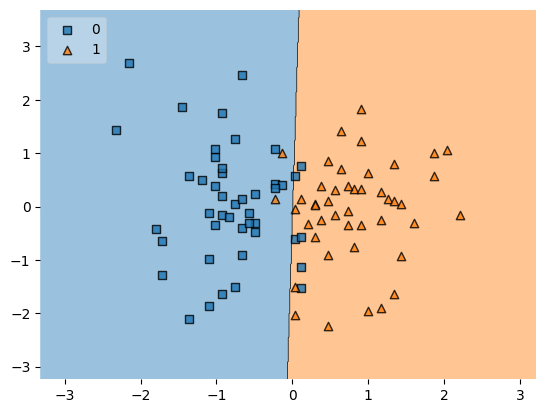

In [27]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [28]:
import pickle

In [29]:
pickle.dump(clf,open('model.pkl','wb'))